In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("movies_metadata.csv")

In [4]:
df = df[['budget', 'rating']].dropna() # select only the relevant columns and drop missing values
df = df[df['budget'] != 0] # exclude rows with zero budget
df['budget'] = pd.to_numeric(df['budget'], errors='coerce') # convert budget to numeric type

In [5]:
X = df[['budget']]
y = df['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(X_test)

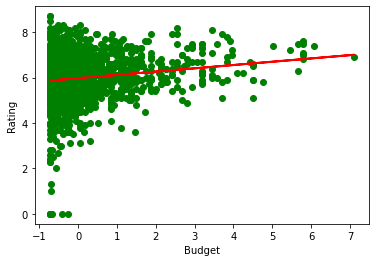

In [11]:
plt.scatter(X_test, y_test, color='green')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.xlabel('Budget')
plt.ylabel('Rating')
plt.show()

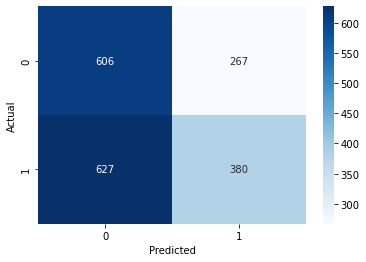

In [12]:
y_pred_class = np.where(y_pred > np.mean(y_pred), 1, 0) # convert ratings to binary classes based on the mean
y_test_class = np.where(y_test > np.mean(y_test), 1, 0)
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
total_samples = sum(sum(cm))
accuracy = (cm[0,0] + cm[1,1]) / total_samples
print("Accuracy:", accuracy)

Accuracy: 0.524468085106383


In [ ]:
#logistic regression. take a value and make sure i can back up why 6 is the cutoff
#randomforest classifier
#look at acc of training set 